El propósito de este *notebook* es mostrar la lógica tras los procesos de extracción masiva y selección de características mediante una ejecución. 

Asimismo, para probar conclusiones robustas sobre el enfoque tabular, se crearán en la última celda varios *datasets* en base a:

- Número máximo de nulos consecutivos aceptado.
- Distintas particiones de ventanas.

De esta forma, se probará la toma de decisiones más óptima en base a resultados empíricos.

A grandes rasgos, el *pipeline* de la ingeniería de características seguirá el siguiente enfoque:
1. Iteraciones necesarias entre el preprocesamiento (en base al `01_EDA.ipynb`) y extracción de características. Ejemplo: extraer características de nulos, seguidamente interpolar y calcular otras variables.
2. Filtro de correlación para prescindir de variables altamente correlacionadas.
3. Selección de características mediante *BorutaShap*. 
    * Aunque la utilidad de este paso se muestre aquí, se realizará en el `03_ML_modeling.ipynb`.

In [1]:
import pandas as pd
import os
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, matthews_corrcoef, recall_score, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
###########################################################################################
# Para usar una versión actualizada de SciPy & Numpy, no cambiar el orden de estos imports
# Ver hilo de incompatibilidad en: https://github.com/Ekeany/Boruta-Shap/issues/130
import scipy.stats as stats
if not hasattr(stats, "binom_test"):
    stats.binom_test = lambda x, n, p, alternative: stats.binomtest(k=int(x), n=int(n), p=p, alternative=alternative).pvalue

np.NaN = np.nan # Necesario con NumPy >= 2.0
from BorutaShap import BorutaShap
###########################################################################################
from config import SEED
import utils
import feature_extraction

# 1. Lógica del flujo de ingeniería de características

## 1.1 Preprocesamiento y extracción

En primer lugar, se evitan los registros extremadamente inconsistentes o que carecen de valor predictivo (clientes inactivos, varios años sin registro, etc.).

In [2]:
df = pd.read_csv('data/dataset.csv')

df = (df
    .pipe(utils.drop_industrial_client)                     # Elimina al cliente industrial (solo 1, se usa su id)
    .pipe(utils.drop_clientID)                              # Elimina la columna 'CONS_NO' (Consumer Number)
    .pipe(utils.drop_duplicated_rows)                       # Elimina filas duplicadas
    .pipe(utils.drop_inactive_clients)                      # Elimina clientes inactivos: solo 0s y/o nulos
    .pipe(utils.drop_n_not_consecutive_values, n=60)        # Elimina clientes sin al menos 60 valores no nulos consecutivos
    .pipe(utils.drop_large_max_gaps, max_gap_threshold=670) # Elimina un mínimo de clientes con gaps internos enormes
)

print("Shape:", df.shape)
print("Distribution of Fraud values:")
print(df['FLAG'].value_counts(normalize=True))
df.head(2)

Shape: (40104, 1035)
Distribution of Fraud values:
FLAG
0    0.912428
1    0.087572
Name: proportion, dtype: float64


,1/1/2014,1/2/2014,1/3/2014,1/4/2014,1/5/2014,1/6/2014,1/7/2014,1/8/2014,1/9/2014,1/10/2014,...,10/23/2016,10/24/2016,10/25/2016,10/26/2016,10/27/2016,10/28/2016,10/29/2016,10/30/2016,10/31/2016,FLAG
0,0.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.83,0.02,0.06,0.58,0.89,0.35,0.38,0.70,0.25,1
1,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.91,17.13,14.32,16.37,26.33,19.06,17.38,13.94,14.14,1


Antes de recortar la serie entre el inicio y el fin del registro (por cliente) se extrae la variable operativa sobre la fecha de entrada y la antigüedad.

In [3]:
df_entry = feature_extraction.extract_entry_and_lifespan(df)
df_entry.tail(2)

,relative_entry_point,lifespan
40102,0.219748,807
40103,0.706680,304


Después se aplica el recorte.

In [4]:
X_trimmed = utils.get_trimmed_series(df)
# Se comprueban las dimensiones esperadas
X_trimmed_shapes = set(arr.shape[0] for arr in X_trimmed)
print("Unique shapes:", X_trimmed_shapes)

Unique shapes: {60, 62, 71, 72, 73, 75, 76, 79, 81, 88, 89, 94, 95, 96, 100, 101, 103, 104, 105, 110, 114, 115, 116, 117, 121, 122, 123, 124, 126, 130, 133, 136, 138, 139, 144, 151, 153, 156, 157, 163, 165, 170, 172, 183, 184, 186, 190, 191, 192, 193, 195, 198, 199, 202, 205, 207, 212, 213, 214, 215, 216, 217, 221, 226, 227, 228, 229, 231, 233, 234, 236, 237, 239, 241, 242, 243, 244, 247, 248, 251, 252, 255, 257, 258, 259, 265, 266, 267, 269, 270, 271, 272, 276, 277, 279, 282, 284, 285, 286, 288, 289, 290, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 394, 397, 412, 436, 446, 447, 450, 451, 453, 461, 478, 481, 489, 524, 544, 546, 554, 556, 565, 569, 577, 587, 589, 597, 598, 613, 625, 633, 640, 644, 654, 665, 671, 675, 677, 681, 684, 690, 694, 696, 701, 705, 707, 709, 710, 711, 713, 715, 717, 719, 720, 721, 722, 724, 727, 728, 729, 730, 731, 732, 733, 735, 741, 743, 745, 746, 747, 748, 749, 750, 751, 752, 753, 754, 755, 756, 757, 758, 759, 760, 761, 762, 763, 764, 765

Se extraen valores sospechosos de fraude: ceros y nulos.

In [5]:
df_zeros = feature_extraction.extract_zero_features(X_trimmed)
df_zeros.head(2)

,zeros_ratio,zeros_max_streak,zeros_mean_streak,zeros_std_streak,zeros_median_streak,zeros_spread_ratio,zeros_first_half_ratio,zeros_second_half_ratio,zeros_center_of_mass,zero_trans_ratio,zero_stay_prob,long_zero_streak_ratio,zero_blocks_ratio,zero_gap_mean,zero_gap_std,zero_gap_max,recent_30d_zero_ratio,recent_60d_zero_ratio,zero_longest_streak_ratio
0,0.833656,374.0,41.047619,89.801621,3.0,0.987427,0.773694,0.893617,0.497581,0.039652,0.975638,0.333333,0.020309,1.184669,3.772515,111.0,0.133333,0.366667,0.361702
1,0.048356,50.0,50.000000,0.000000,50.0,0.048356,0.096712,0.000000,0.023694,0.000967,0.980000,1.000000,0.000967,1.000000,0.000000,1.0,0.000000,0.000000,0.048356


In [6]:
df_nulls = feature_extraction.extract_null_features(X_trimmed)
df_nulls.head(2)

,nulls_ratio,nulls_streaks_count,nulls_max_consecutive,nulls_mean_consecutive,nulls_short_gaps_ratio,nulls_long_gaps_ratio,nulls_first_idx_ratio,nulls_last_idx_ratio,nulls_temporal_skew,nulls_longest_gap_ratio,nulls_entropy,nulls_abs_step_change_mean,nulls_step_change_mean,nulls_step_drop_ratio,nulls_step_rise_ratio,nulls_fragmentation,nulls_inter_gap_dist_mean,nan_start_prob
0,0.003868,3,2,1.333333,1.000000,0.000000,0.104449,0.536750,-0.278530,0.001934,1.039721,0.056667,0.056667,0.000000,0.333333,0.750000,0.214700,0.002913
1,0.181818,9,158,20.888889,0.777778,0.111111,0.048356,0.944874,0.147424,0.152805,1.067929,3.700000,3.595556,0.444444,0.555556,0.047872,0.089458,0.010638


Una vez se han extraído las características no dependientes de la cantidad de consumo positivo, es indispensable limpiar las lecturas erróneas. Se aplica tanto sobre las series recortadas (sin fechas) como sobre el conjunto original para extraer aquellas variables dependientes de la temporalidad (usan meses, estaciones, etc.).

In [7]:
# Limpia errores de medición: valores desproporcionalmente extremos
# Los sustituye por NaN e interpola linealmente máx. 2 días internamente
df_no_errors = utils.interpolate_spikes(df)
X_trimmed_no_errors = utils.get_trimmed_series(df_no_errors)

In [8]:
df_seasonal = feature_extraction.extract_seasonal_features(df_no_errors)
df_seasonal.head(2)

,summer_std,winter_std,summer_skew,winter_skew,summer_kurtosis,winter_kurtosis,summer_masd,winter_masd,sum_win_mean_ratio,sum_win_max_ratio,...,summer_slope,winter_slope,sum_win_slope_diff,annual_slope,trend_acceleration,max_monthly_shift,annual_cv,peak_month,lowest_month,transitional_ratio
0,2.438622,3.693045,3.820967,3.018503,13.561945,7.955670,0.155727,0.336390,0.520230,0.788955,...,-0.899916,-1.30511,0.405194,-1.096164,1.514330,2.956427,3.261388,12,2,0.091531
1,8.818545,2.218610,1.293815,1.007712,1.448288,-0.799934,1.018460,0.240972,4.161179,6.304093,...,7.886767,2.40435,5.482417,5.693546,11.405705,8.188108,1.551039,9,12,2.930244


Se extraen características de dominio en base al *EDA*.

In [9]:
# Importante: posteriormente se aplicará un filtro de correlación entre otros
# si el número de particiones (n_windows) es muy elevado, aumenta el riesgo de perder información relevante
df_consumption = feature_extraction.extract_consumption_features(X_trimmed_no_errors, n_windows=2)
df_consumption.head(2)

,cons_global_mean,cons_global_cv,cons_global_skewness,cons_global_kurtosis,cons_global_iqr,cons_global_percentile_spread,cons_global_extreme_peak_ratio,cons_global_masd,cons_global_diff_var,cons_global_trend_slope,...,w2_kurtosis,w2_peak_ratio,w2_masd,w2_trend_slope,w2_energy_ratio,w2_spread,w2_mean_crossings,windows_cv_volatility,windows_masd_max_ratio,windows_mean_shift
0,0.951185,3.259810,3.470561,11.199003,0.00,5.752189,1.440360e+06,0.222314,0.828308,-0.001932,...,19.187048,29600.000000,0.035911,0.000343,0.000841,0.89,0.059961,0.776854,11.390244,55.121006
1,4.579495,1.550138,2.128441,5.075720,4.94,1.161825,2.780830e+01,0.674047,2.726309,0.021087,...,1.811293,4.078537,1.277483,0.056861,0.996244,44.28,0.011628,0.105163,17.370107,14.698162


Como penúltimo paso en el proceso de extracción se emplea `TSFEL`. 

Más allá de la interpolación mínima de ≤2 días internos para limpiar errores de medición, **este es el único punto de la extracción donde se imputan valores nulos**. La estrategia de imputación ya se definió en el *EDA*:
- Extracción de variables relacionadas con los nulos: hecha.
- Imputación solo cuando sea estrictamente necesaria: lo es con TSFEL.
- *Gaps* internos ≤7 días mediante interpolación lineal.
- *Gaps* internos >7 días usando la mediana mensual del cliente.
    - Si no es posible, con su mediana global.

Con todo, cabe añadir una condición. Como se observa en el siguiente gráfico, existe una cantidad muy reducida de series con menos de 180 días registrados. Para poder aplicar parámetros extractivos en `TSFEL` que resulten mínimamente representativos para la mayoría —en lugar de fijar el mínimo de 60 días—, estas series se extienden hasta alcanzar los 180 días rellenando de forma simétrica con su primer y último valor. De este modo, la extracción no queda condicionada a capturar únicamente patrones de corta escala, como los semanales o, a lo sumo, mensuales.

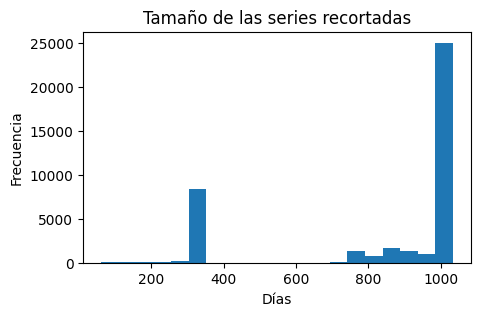

In [10]:
sizes = [arr.shape[0] for arr in X_trimmed]
plt.figure(figsize=(5, 3))
plt.hist(sizes, bins=20)
plt.title('Tamaño de las series recortadas')
plt.xlabel('Días')
plt.ylabel('Frecuencia')
plt.show()

In [11]:
X_trimmed_imputed = utils.get_imputed_trimmed_series(df_no_errors)
X_trimmed_imputed_shapes = set(arr.shape[0] for arr in X_trimmed_imputed)
print("Unique shapes:", X_trimmed_imputed_shapes)

Unique shapes: {180, 183, 184, 186, 190, 191, 192, 193, 195, 198, 199, 202, 205, 207, 212, 213, 214, 215, 216, 217, 221, 226, 227, 228, 229, 231, 233, 234, 236, 237, 239, 241, 242, 243, 244, 247, 248, 251, 252, 255, 257, 258, 259, 265, 266, 267, 269, 270, 271, 272, 276, 277, 279, 282, 284, 285, 286, 288, 289, 290, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 394, 397, 412, 436, 446, 447, 450, 451, 453, 461, 478, 481, 489, 524, 544, 546, 554, 556, 565, 569, 577, 587, 589, 597, 598, 613, 625, 633, 640, 644, 654, 665, 671, 675, 677, 681, 684, 690, 694, 696, 701, 705, 707, 709, 710, 711, 712, 715, 717, 719, 720, 721, 722, 724, 727, 728, 729, 730, 731, 732, 733, 735, 741, 743, 745, 746, 747, 748, 749, 750, 751, 752, 753, 754, 755, 756, 757, 758, 759, 760, 761, 762, 763, 764, 765, 766, 767, 768, 769, 771, 772, 773, 774, 775, 776, 778, 780, 781, 782, 783, 785, 786, 787, 788, 789, 790, 791, 792, 793, 794, 795, 796, 797, 798, 799, 800, 801, 802, 803, 804, 805, 806, 807, 808,

Con los nulos imputados ya es posible la extracción en 4 dominios: espectral, fractal, estadístico y temporal. La lista completa se encuentra en la documentación: [module-tsfel.feature_extraction.features](https://tsfel.readthedocs.io/en/latest/descriptions/modules/tsfel.feature_extraction.html#module-tsfel.feature_extraction.features).

De las 68 características disponibles, no se usará la siguiente. 
*   [*human_range_energy*](https://tsfel.readthedocs.io/en/latest/descriptions/modules/tsfel.feature_extraction.html#tsfel.feature_extraction.features.human_range_energy): la publicación académica de *TSFEL* [1] revela que se utiliza para el estudio del comportamiento humano (ver: *Fernandes, L (2019) et. al* [2]), además, se comprende en un rango de 0.6-2.5Hz, es decir, entre 0.4 y 1.67 segundos por ciclo. Por lo tanto, este valor carece de utilidad.

Seguidamente, algunas *features* dependen de la elección de ciertos hiperparámetros. En su mayoría son simples y emplean la propia señal (`signal`) y la frecuencia de muestreo (`fs` = 1), que es diaria. Sin embargo, otras deben ajustarse en función del rango mínimo de la serie y del nivel de consistencia deseado (por ejemplo, cálculo de una media con 20 días o 3 meses).

* Valores `max_width` en variables `wavelet`: *Continuous Wavelet Transform (CWT)* permite analizar la señal en diferentes escalas temporales. De acuerdo con la [implementación de la librería](https://tsfel.readthedocs.io/en/latest/_modules/tsfel/feature_extraction/features.html#wavelet_energy), cada valor de `width` representa la escala de análisis asociada al tamaño del patrón temporal que se desea detectar. Valores bajos permiten capturar cambios rápidos y comportamiento local, mientras que valores altos capturan tendencias más largas y patrones de baja frecuencia.
    * Como valor intermedio se fija: `max_width=30`

    > Ver también (Aguiar-Conraria, L (2014) et. al): "*is its ability to adjust to the local analysis of a time series in the sense that the length of the wavelets varies endogenously: it stretches into a long wavelet
function to measure the low-frequency movements; and it compresses into a short wavelet function to measure the high-frequency movements.*" [3]

* Valor `bins` en `spectrogram_mean_coeff`: variable que recoge la energía media de la densidad espectral por cada rango de frecuencia. De acuerdo con la [implementación de TSFEL](https://tsfel.readthedocs.io/en/latest/_modules/tsfel/feature_extraction/features.html#spectrogram_mean_coeff), *bins* controla indirectamente el tamaño de la ventana temporal utilizada en el espectrograma (`nperseg = bins * 2 - 2`). Valores altos generan ventanas más largas, mejorando la resolución espectral a costa de perder detalle temporal (variaciones locales).
    * Dado el tamaño mínimo y que la mayoría de las series son mucho mayores, se establece: `bins = 64`.

    > Ver también la documentación de [Scipy 1.17.0 sobre spectrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.spectrogram.html), parámetro `nperseg`: "*Length of each segment*".

* Valor `n` en `neighbourhood_peaks`: captura el número de vecinos cercanos —a izquierda y derecha— que son picos locales.
    * Se establece en `n=14` (14 a derecha y 14 a izquierda) para comparar picos mensuales.

* Valores relacionados con `ecdf`: la *Empirical Cumulative Distribution Function (ECDF)* retrata cómo se distribuyen los valores en una muestra, respondiendo a cuántos valores son superiores o menores que *X*. Para estas métricas se plantea un valor alto de percentil (`[0.1, 0.9]`) para capturar la distribución de los valores extremos. Similarmente, en `ecdf_slope` se proponen `p_init` y `p_end` entre `0.5` y `0.85` para registrar cómo de empinada es la diferencia entre las distribuciones de los valores de consumos medios y altos (los picos máximos se estudian con otras variables). 

* Valor `nbins` de `hist_mode`: obtiene la moda de un histograma con *nbins*. 
    * Se aumenta la resolución por defecto (10) con `nbins=20`.

* Valores de `mfcc`: los Coeficientes Cepstrales en las Frecuencias de Mel (*MFCC*) permiten representar una señal mediante un conjunto reducido de valores que resumen cómo se distribuye su energía en distintas frecuencias. Se emplean como método de extracción de características de audio, pero se valorará si puede tener utilidad en este contexto. De forma simplificada, el proceso consiste en transformar la señal al dominio de la frecuencia (FFT), agrupar las frecuencias en bandas y comprimir la información resultante en un número reducido de coeficientes. Se valora:

    * `pre_emphasis` es una transformación que amplifica frecuencias altas; se fija en `0` para evitar introducir distorsiones innecesarias dado el contexto (no es necesario transformar audio). Ver la publicación usada para su implementación: [*blog de Haytham Fayek, 2016*](https://haythamfayek.com/2016/04/21/speech-processing-for-machine-learning.html).
    * `nfft` define el tamaño del fragmento analizado: valores bajos capturan variaciones locales, mientras que valores altos capturan tendencias más globales.
    * `nfilt` indica el número de bandas de frecuencia utilizadas; a mayor valor, mayor detalle espectral.
    * `num_ceps` es el número de coeficientes finales retenidos; a mayor valor, mayor cantidad de información conservada.
    * Considerando el tamaño mínimo de las series se establece: `nfft = 128`, `nfilt = 20`, `num_ceps = 8`.

* Valores `n_coeff` en `lpcc`: también destinados a señales de audio, los Coeficientes Cepstrales de Predicción Lineal (*LPCC*) representan la señal a partir de la relación entre sus valores pasados, capturando estructura y regularidad.
    * También se extraen `n_coeff = 8`.

---

*[1] Barandas, M. et al. (2020) TSFEL: Time Series Feature Extraction Library. SoftwareX. [Online] 11.*

*[2] Fernandes, L. M. S. (2019) Learning Human Behaviour Patterns by Trajectory and Activity Recognition. ProQuest Dissertations & Theses.*

*[3] Aguiar-Conraria, L. & Soares, M. J. (2014) THE CONTINUOUS WAVELET TRANSFORM: MOVING BEYOND UNI- AND BIVARIATE ANALYSIS. Journal of economic surveys. [Online] 28 (2), 344–375.*

In [12]:
# Por ser computacionalmente costoso se guarda.
# Parte del dataset "crudo" por si se desea ejecutar fuera del notebook
# hace el mismo preprocesamiento de la 1a celda del punto 1
df_raw = pd.read_csv('data/dataset.csv')
output_path = 'data/tsfel_datasets/'
feature_extraction.create_and_save_tsfel_datasets(df_raw, output_path=output_path)

Preprocessing raw dataset for TSFEL extraction...


TSFEL: extracting features...: 100%|██████████| 40104/40104 [15:39<00:00, 42.69it/s]



Features after removing constants: 155
Removed 84 highly correlated features.
Final TSFEL features count: 71
Total missing values: 10 | Filling with 0 before saving
 * Succesfully created & saved: data/tsfel_datasets/tsfel_features_gap670.csv
 * Succesfully created & saved: data/tsfel_datasets/tsfel_features_gap250.csv


Como paso previo a la unión, se ha aplicado un filtro de correlación de Pearson (>0.95) para eliminar redundancia extrema entre variables, manteniendo la diversidad de representaciones sin introducir una pérdida significativa de información. Asimismo, se evitan almacenar ≈85 columnas adicionales.

Siguiendo con el ejemplo del flujo extractivo se unen los conjuntos creados y se vuelve a filtrar por correlación por el mismo motivo.

In [13]:
# Unión
df_tsfel = pd.read_csv('data/tsfel_datasets/tsfel_features_gap670.csv')
df_final = pd.concat([df_entry, df_zeros, df_nulls,
                      df_seasonal, df_consumption, df_tsfel],
                       axis=1)
print("Initial Shape:", df_final.shape)

# Pearson > 0.95
corr_matrix = df_final.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
df_final = df_final.drop(columns=to_drop)
print(f"Dropped {len(to_drop)} columns due to high correlation")
print("Final shape:", df_final.shape)

# Guardado
os.makedirs('data/all_features', exist_ok=True)
df_final.to_csv('data/all_features/gap670_windows2.csv', index=False)

Initial Shape: (40104, 185)
Dropped 24 columns due to high correlation
Final shape: (40104, 161)


Como paso final del flujo extractivo, se valora la adición de la detección de anomalías mediante *Isolation Forest*. Esta decisión se fundamenta en los hallazgos del *EDA*, donde se identificó que "*el fraude mantiene cierta dependencia temporal local, pero [...] tienen desniveles en el consumo o patrones irregulares*".

In [ ]:
# Split estratificado
df_final = pd.read_csv('data/all_features/gap670_windows2.csv')
X = df_final.drop(columns=['FLAG'])
y = df_final['FLAG']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=SEED, stratify=y
)

# Entreno con 300 árboles y el porcentaje de fraude como tasa de contaminación 
contamination_rate = y_train.mean()
iso = IsolationForest(
    n_estimators=300,
    contamination=contamination_rate,
    random_state=SEED,
    n_jobs=-1
)
iso.fit(X_train)

# Se evalúa maximizando el MCC ¡SOLO para valorar si es útil!
# En el conjunto final solo se añaden los scores, no la predicción
y_pred = iso.predict(X_test)
y_pred = np.where(y_pred == -1, 1, 0)
mcc = matthews_corrcoef(y_test, y_pred)
base_recall = recall_score(y_test, y_pred) 
print(f"MCC Initial: {mcc:.4f}")
print(classification_report(y_test, y_pred, digits=4))

# Prueba adicional que maximiza recall y mcc (para conclusiones)
scores = iso.decision_function(X_test)
thresholds = np.linspace(scores.max(), scores.min(), 100)
best_mcc = -1
best_threshold = None
for t in thresholds:
    y_pred_t = (scores <= t).astype(int)
    rec_t = recall_score(y_test, y_pred_t)
    if rec_t >= base_recall:
        mcc_t = matthews_corrcoef(y_test, y_pred_t)
        if mcc_t > best_mcc:
            best_mcc = mcc_t
            best_threshold = t

y_pred_opt = (scores <= best_threshold).astype(int)
print(f"MCC Optimized: {best_mcc:.4f} | Threshold: {best_threshold:.2f}")
print(classification_report(y_test, y_pred_opt, digits=4))

MCC Initial: 0.0513
              precision    recall  f1-score   support

           0     0.9169    0.9159    0.9164     10978
           1     0.1341    0.1357    0.1349      1054

    accuracy                         0.8476     12032
   macro avg     0.5255    0.5258    0.5257     12032
weighted avg     0.8484    0.8476    0.8480     12032

MCC Optimized: 0.0962 | Threshold: 0.10
              precision    recall  f1-score   support

           0     0.9529    0.3245    0.4841     10978
           1     0.1059    0.8330    0.1878      1054

    accuracy                         0.3690     12032
   macro avg     0.5294    0.5787    0.3360     12032
weighted avg     0.8787    0.3690    0.4581     12032



En la implementación de [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html#:~:text=to%20define%20the%20threshold), *Isolation Forest* utiliza la proporción esperada de anomalías (*contamination* ≈ 8–9%) como umbral de decisión, restringiendo la clasificación positiva únicamente a las observaciones más extremas. Como resultado, se obtiene un *recall* muy bajo (≈0.14), dejando la mayor parte del fraude sin detectar al no encontrarse en la región más aislada del espacio de características.

Al optimizar el umbral en base al *MCC* y con un *recall* mínimo, la tasa de detección aumenta a ≈0.85. El coste de esta ganancia implica un *threshold* de 0.1 (espacio de características muy común), una proporción de falsos positivos de casi el 70% y un *MCC* prácticamente nulo (≈0.1). Por tanto, este experimento evidencia que la gran mayoría del fraude no tiene un comportamiento estadísticamente anómalo, sino que regularmente se encuentra, según estas variables, camuflado entre patrones de consumo legítimos.

Con todo, puesto que se empleará un método de selección de características en base a su importancia, se incorporará el *score* de anomalía (sin umbral ni predicción) como nueva variable. Permitiendo a los modelos supervisados —si pasa el filtro— explotar esta señal continua para aprender de forma más precisa qué regiones anómalas son realmente discriminativas gracias al combinar información multivariante. Para evitar *data leakage*, estos valores se calcularán a partir del ajuste con los datos de entrenamiento. Así, la distribución de anomalías se aprende exclusivamente con el conjunto conocido, manteniendo aislados los datos de evaluación y test.

In [15]:
df_final['IF_Score'] = iso.decision_function(X)

## 1.2. Selección de *features*

Con el fin de evitar cualquier riesgo de *data leakage* se realiza la selección de características sobre el conjunto de entreno y evaluación. El primero se emplea para crear los conjuntos y el segundo para validar, en una ocasión, la técnica de selección. De este modo, se mantiene siempre el test aislado para la evaluación final.

In [16]:
train_df, validation_df, test_df = utils.stratified_train_val_test_split(df_final) # 70, 15, 15 

# Ver estratificación correcta 
partitions = {'Train': train_df, 'Val': validation_df, 'Test': test_df}
for split_name, split_df in partitions.items():
    fraud_ratio = split_df['FLAG'].mean()
    print(f"{split_name} -> shape = {split_df.shape} | fraud_ratio = {fraud_ratio:.4f}")

Train -> shape = (28072, 162) | fraud_ratio = 0.0876
Val -> shape = (6016, 162) | fraud_ratio = 0.0876
Test -> shape = (6016, 162) | fraud_ratio = 0.0876


### BorutaSHAP

La estrategia elegida para la selección de características es *BorutaSHAP*, que combina el enfoque de *Boruta* con valores *SHAP*. El método genera variables aleatorias (*shadow features*) estimando sus valores *SHAP*, sobre los que se obtiene el máximo y se fija como umbral a superar por cada variable original. Se mantienen únicamente aquellas que lo superan de forma consistente.

Uno de los puntos fuertes —especialmente relevante en este contexto— es la posibilidad de emplear distintos modelos de árboles para el filtrado. En este ejemplo ilustrativo se utiliza *LightGBM*, pero el proceso puede repetirse con otros algoritmos como *XGBoost* y *CatBoost*. De este modo, se obtienen conjuntos de características adaptados a cada modelo y, en caso de emplear estrategias como *stacking* o *soft voting*, se puede incrementar la diversidad del sistema al trabajar con distintos subconjuntos de variables.

En cada caso, el algoritmo que emplee *BorutaShap* usará una configuración exploratoria, combinando árboles poco profundos y capacidad limitada (por ejemplo, restricciones en *max_depth* o *num_leaves*) con técnicas de remuestreo y selección aleatoria de variables (*subsample* y *colsample_bytree*). De este modo, se evita un ajuste excesivo a patrones muy específicos o a óptimos locales, favoreciendo una estimación de importancias más robusta.

In [17]:
X_train = train_df.drop(columns='FLAG')
y_train = train_df['FLAG']

# Modelo "explorador"
lgbm_boruta = LGBMClassifier(
    # Fuente: https://lightgbm.readthedocs.io/en/latest/Parameters.html
    extra_trees=True,          # Randomiza los cortes, "when evaluating node splits LightGBM will check only one randomly-chosen threshold for each feature"
    n_estimators=200,          # Suficientes iteraciones para estabilizar SHAP
    max_depth=5,               # Árboles poco profundos
    num_leaves=20,             # Se reducen las hojas por árbol para mayor generalización
    min_child_samples=30,      # Evita overfitting, al menos 30 clientes por hoja final
    colsample_bytree=0.5,      # Solo usa el 50% de variables en cada árbol
    feature_fraction_bynode=0.8, # 80% de variables en cada split
    subsample=0.8,             # 80% de las filas aleatoriamente por árbol
    subsample_freq=1,          # Activa el subsample (anterior) en cada iteración
    scale_pos_weight=10.4,     # Penaliza más los errores de fraude (91.24 / 8.76)
    n_jobs=-1,
    random_state=SEED,
    verbose=-1
)

# Filtro Bortua con SHAP sobre el train
boruta_selector = BorutaShap(model=lgbm_boruta, importance_measure='shap', classification=True)
boruta_selector.fit(
    X=X_train,
    y=y_train,
    n_trials=100,
    random_state=SEED,
    sample=False,
    train_or_test='train',
    normalize=True,
    verbose=True,
)

# Se aceptan las variables tentativas (al límite)
selected_features = list(dict.fromkeys(list(boruta_selector.accepted) + list(boruta_selector.tentative)))

  0%|          | 0/100 [00:00<?, ?it/s]

38 attributes confirmed important: ['w2_trend_slope', '0_Wavelet entropy', 'nulls_last_idx_ratio', 'nulls_mean_consecutive', 'winter_std', '0_Spectral variation', 'nulls_streaks_count', '0_Mean diff', 'nulls_entropy', 'cons_global_trend_slope', '0_Wavelet absolute mean_0.25Hz', '0_MFCC_4', 'zeros_center_of_mass', '0_Spectral spread', 'winter_skew', 'nulls_step_change_mean', '0_Spectrogram mean coefficient_0.03Hz', 'sum_win_max_ratio', 'w2_peak_ratio', 'nulls_first_idx_ratio', 'w1_mean_crossings', 'windows_cv_volatility', 'max_monthly_shift', '0_MFCC_0', 'nulls_short_gaps_ratio', 'nulls_abs_step_change_mean', 'w1_trend_slope', 'plateau_type', 'annual_cv', 'nan_start_prob', 'w2_spread', 'nulls_fragmentation', 'transitional_ratio', 'summer_slope', '0_Spectral positive turning points', 'zeros_std_streak', 'summer_kurtosis', 'w1_cv']
115 attributes confirmed unimportant: ['w1_energy_ratio', '0_Spectral roll-on', '0_Spectral decrease', '0_MFCC_6', 'cons_global_shannon_entropy', '0_MFCC_7', '

In [18]:
print(f'Selected features: {len(selected_features)}')
print(selected_features)

Selected features: 46
['w2_trend_slope', '0_Wavelet entropy', 'nulls_last_idx_ratio', 'nulls_mean_consecutive', 'winter_std', '0_Spectral variation', 'nulls_streaks_count', '0_Mean diff', 'nulls_entropy', 'cons_global_trend_slope', '0_Wavelet absolute mean_0.25Hz', '0_MFCC_4', 'zeros_center_of_mass', '0_Spectral spread', 'winter_skew', 'nulls_step_change_mean', '0_Spectrogram mean coefficient_0.03Hz', 'sum_win_max_ratio', 'w2_peak_ratio', 'nulls_first_idx_ratio', 'w1_mean_crossings', 'windows_cv_volatility', 'max_monthly_shift', '0_MFCC_0', 'nulls_short_gaps_ratio', 'nulls_abs_step_change_mean', 'w1_trend_slope', 'plateau_type', 'annual_cv', 'nan_start_prob', 'w2_spread', 'nulls_fragmentation', 'transitional_ratio', 'summer_slope', '0_Spectral positive turning points', 'zeros_std_streak', 'summer_kurtosis', 'w1_cv', '0_LPCC_0', 'cons_global_diff_var', 'w2_kurtosis', 'relative_entry_point', '0_Spectrogram mean coefficient_0.06Hz', 'cons_global_spectral_entropy', 'cons_global_acf_30', 'n

In [ ]:
# Comparativa de métricas con y sin selección de características
X_val = validation_df.drop(columns='FLAG') 
y_val = validation_df['FLAG'] 
print("== Validation Set Metrics ==\n")

# Filtradas
print(f"Boruta-Shap selected features ({len(selected_features)})")
lgbm_boruta.fit(X_train[selected_features], y_train)
y_pred = lgbm_boruta.predict(X_val[selected_features])
y_prob = lgbm_boruta.predict_proba(X_val[selected_features])[:, 1]

roc_auc = roc_auc_score(y_val, y_prob)
pr_auc = average_precision_score(y_val, y_prob)
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}\n")

# Sin filtrar
print(f"All features ({X_train.shape[1]})") 
lgbm_boruta.fit(X_train, y_train) 
y_pred_all = lgbm_boruta.predict(X_val)
y_prob_all = lgbm_boruta.predict_proba(X_val)[:, 1]

roc_auc_all = roc_auc_score(y_val, y_prob_all)
pr_auc_all = average_precision_score(y_val, y_prob_all)
print(f"ROC-AUC: {roc_auc_all:.4f}")
print(f"PR-AUC:  {pr_auc_all:.4f}\n")

== Validation Set Metrics ==

Boruta-Shap selected features (46)
ROC-AUC: 0.8263
PR-AUC:  0.4466

All features (161)
ROC-AUC: 0.8295
PR-AUC:  0.4703



Notando que la ganancia de rendimiento predictivo es muy reducida, mientras, se han eliminado más de 110 variables residuales. Adicionalmente, puede visualizarse la comparativa mediante la eliminación recursiva con validación cruzada (*RFECV*) sobre el conjunto de entrenamiento.

In [20]:
# Modelo para testear: nueva configuración menos "exploradora"
lgbm_test = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=25,
    colsample_bytree=0.8,
    subsample=0.9,
    subsample_freq=1,
    scale_pos_weight=10.41,
    min_split_gain=0.01,
    n_jobs=-1,
    random_state=SEED,
    verbose=-1
)

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
# Límite inferior de 15 y eliminando 3 variables por iteración 
# en el conjunto completo (más costoso)
rfecv_selector_global = RFECV(
    estimator=lgbm_test, 
    step=3,
    cv=cv_strat,
    scoring="average_precision",
    min_features_to_select=15,
    n_jobs=-1
)
# Igualmente para BorutaShap pero con step=1
rfecv_selector_boruta = RFECV(
    estimator=lgbm_test, 
    step=1,
    cv=cv_strat,
    scoring="average_precision",
    min_features_to_select=15,
    n_jobs=-1
)

# Entreno
rfecv_selector_global.fit(X_train, y_train)
rfecv_selector_boruta.fit(X_train[selected_features], y_train)
# Resultados
features_global = np.array(X_train.columns)[rfecv_selector_global.support_].tolist()
features_boruta = np.array(selected_features)[rfecv_selector_boruta.support_].tolist()

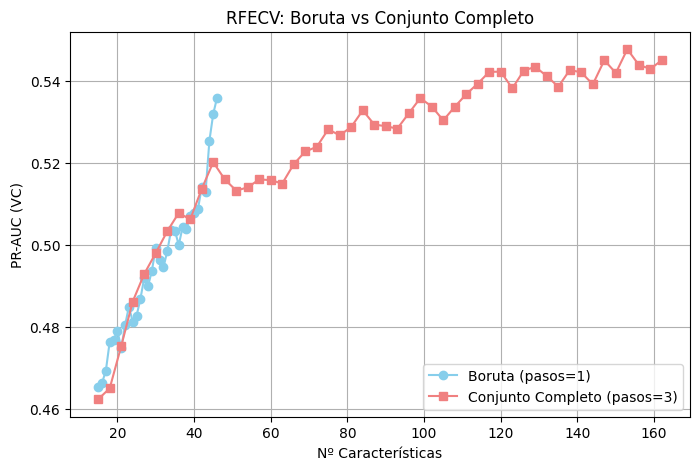

In [21]:
# Boruta + RFECV (step=1)
min_features = 15
n_features_boruta = range(min_features, min_features + len(rfecv_selector_boruta.cv_results_['mean_test_score']))
# Todas las variables + RFECV (step=3)
step_global = 3
n_features_rfecv = [min_features + step_global * i for i in range(len(rfecv_selector_global.cv_results_['mean_test_score']))]

plt.figure(figsize=(8, 5))
plt.plot(n_features_boruta, rfecv_selector_boruta.cv_results_['mean_test_score'],
         marker='o', color='skyblue', label='Boruta (pasos=1)')
plt.plot(n_features_rfecv, rfecv_selector_global.cv_results_['mean_test_score'],
         marker='s', color='lightcoral', label='Conjunto Completo (pasos=3)')

plt.xlabel('Nº Características')
plt.ylabel('PR-AUC (VC)')
plt.title('RFECV: Boruta vs Conjunto Completo')
plt.grid()
plt.legend(loc='lower right')
plt.show()

Mostrando que el modelo "explorador" inicialmente usado en *BorutaShap* es capaz de captar las variables con más información discriminativa. Para alcanzar el mismo valor de *PR-AUC*, el conjunto completo requiere prácticamente el triple de variables. De modo que, aparentemente, será un buen filtro para los modelos finales al eliminar redundancia, filtrar la información más residual y mejorar la explicabilidad.

# 2. Creación de los conjuntos finales

Una vez mostrada la lógica anterior, se crean distintos *datasets* finales para valorar en el modelaje la toma de decisiones más óptima.

Se consideran las combinaciones conforme a 2 opciones:
1. Número nulos consecutivos más grande (*gaps*) entre datos válidos.
2. Número de particiones de la serie sin solapamiento para variables de `extract_consumption_features`.

In [ ]:
# Asumiendo que ya se ha extraído TSFEL, se ejecuta del siguiente modo:
df_raw = pd.read_csv('data/dataset.csv')

# Ventanas desedas a extraer, limitado a máximo de 12 por coste y 
# para ajustarse a los filtros de correlación (más ventanas, más riesgo de eliminar info relevante)
windows = [2, 4, 8, 12]
# Internamente usa el TSFEL con max_gap y sobre este filtra los índices del
# conjunto más restrictivo (max_gap 250). Evita calcular 2 veces
tsfel_path_larger_gap = 'data/tsfel_datasets/tsfel_features_gap670.csv'
output_path = 'data/all_features/'

feature_extraction.assemble_feature_datasets(df_raw,
                                             windows=windows,
                                             seed=SEED, # seed para Isolation Forest
                                             tsfel_input_dataset_larger_gap_path=tsfel_path_larger_gap,
                                             output_path=output_path)

Preprocessing raw dataset...
Extracting features...

  Successfully created & saved (2 windows):
       - data/all_features/gap670_windows2.csv
         * Total features: 162 | Dropped 24 due to High Correlation
       - data/all_features/gap250_windows2.csv
         * Total features: 162 | Dropped 24 due to High Correlation

  Successfully created & saved (4 windows):
       - data/all_features/gap670_windows4.csv
         * Total features: 181 | Dropped 23 due to High Correlation
       - data/all_features/gap250_windows4.csv
         * Total features: 181 | Dropped 23 due to High Correlation

  Successfully created & saved (8 windows):
       - data/all_features/gap670_windows8.csv
         * Total features: 215 | Dropped 25 due to High Correlation
       - data/all_features/gap250_windows8.csv
         * Total features: 215 | Dropped 25 due to High Correlation

  Successfully created & saved (12 windows):
       - data/all_features/gap670_windows12.csv
         * Total features: 24